In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
df = pd.read_csv("Loan_default.csv")

In [21]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [22]:
# Prediction : LoanAmount
target = "LoanAmount"

# Features 
features = [
    "Age",
    "Income",
    "CreditScore",
    "MonthsEmployed",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "NumCreditLines"
]

In [27]:
x = df[features]
y = df[target]

In [29]:
# it try to makes mean = 0, s.d = 1
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state = 42)

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train, y_train)
print("\nModel Training Completed Successfully")


Model Training Completed Successfully


In [33]:
print("\nIntercept (Bias)")
print(model.intercept_)

print("\nCoefficients")

coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coef_table)


Intercept (Bias)
127547.44553899621

Coefficients
          Feature  Coefficient
0             Age   -72.139348
1          Income   -47.654336
2     CreditScore    76.075917
3  MonthsEmployed   148.798108
4    InterestRate  -270.094612
5        LoanTerm   159.116029
6        DTIRatio   115.610772
7  NumCreditLines    20.072991


In [34]:
# Prediction
y_pred = model.predict(X_test)

In [35]:
comparison = pd.DataFrame({
    "Actual LoanAmount": y_test.values,
    "Predicted LoanAmount": y_pred
})

print("\nActual vs Predicted")

print(comparison.head(10))


Actual vs Predicted
   Actual LoanAmount  Predicted LoanAmount
0              92393         127094.551627
1             131575         127127.850607
2              75417         127323.864868
3              10804         127553.248941
4              21182         128196.894729
5             187008         127395.187297
6             159105         127563.142301
7             173967         127842.577599
8              41189         127253.707419
9             151275         127468.060894


In [39]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)


Model Performance
Mean Squared Error (MSE): 5010264579.079882
Root Mean Squared Error (RMSE): 70783.22244063123
R² Score: -3.3266147294597204e-06


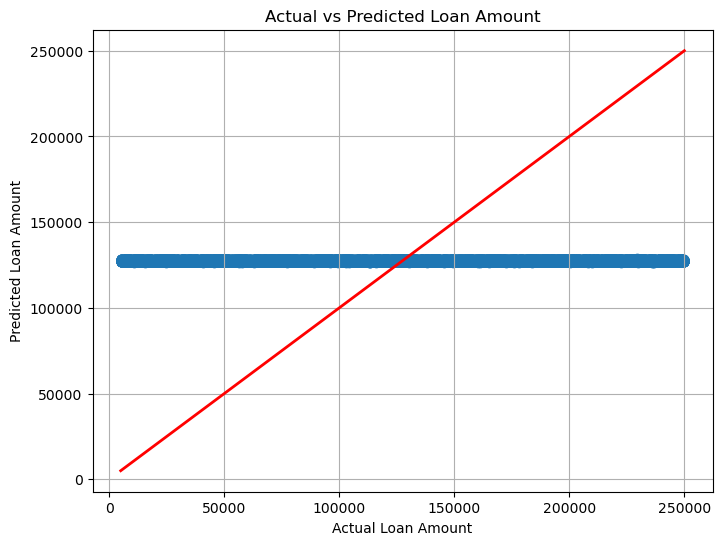

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")

plt.grid(True)

plt.show()